# Evaluating Natural Language Explanations of Food Recommendation System XFoodRec Across Several LLMs

Authors: Junxuan Ling, Tianyi Liu, Anqi Zhou

# 0. Document Instructions

## 0.1. Git Version Control

After making modifications, please use Colab's function of "Save in Github to keep changes" (Github authorization required) to commit the changes to the repository (Your own branch if needed).

**NOTE**: When A modifies this notebook, but have not commited to Github, if B opens this notebook, they will see the Github old version.

## 0.2. Handle persistent data storage

Mount Google Drive instead of relying on Colab's temporary run-time storage.

**IMPORTANT:** Although Google Colab allows collaboration of the notebook, data and folders are originally in Junxuan's drive, this could cause issues when refering to the mounted directory path. To allow the code to work for all of us, (who's not junxuan) please create a **short-cut** of Junxuan's shared folder in our own Google Drive, path `MyDrive/`.

In [1]:
# load from drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# 1. Data Exploration & Preparation

## 1.1. Load and Inspect

### a. Load Data

In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_dir = Path("/content/drive/MyDrive/XFoodRec_Project_Data/raw")
persona_path = data_dir / "personas.json"
recommendation_path = data_dir / "recommendations.json"
recipe_path = data_dir / "recipes.parquet"

In [3]:
# open files and load data

with open(persona_path, "r", encoding="utf-8") as f:
    personas = json.load(f)

with open(recommendation_path, "r", encoding="utf-8") as f:
    recommendations = json.load(f)

recipes = pd.read_parquet(recipe_path)

### b. Inspect Raw data

In [4]:
import json

In [5]:
print("personas")
print("type:", type(personas))
print("length:", len(personas))

print(json.dumps(personas[0],indent=2))

personas
type: <class 'list'>
length: 40
{
  "id": "user_01",
  "description": "A vegan competitive bodybuilder focused on lean bulking without soy overload.",
  "profile": {
    "age": 28,
    "gender": "Male",
    "height": 182.0,
    "weight": 84.0,
    "activityLevel": "very_active",
    "dietary_goal": "Muscle Gain",
    "dietaryProfile": {
      "dietaryRestrictions": {
        "selected": [
          "Vegan"
        ],
        "other": "High-protein, prefers low-soy options"
      },
      "foodAllergies": {
        "selected": [],
        "other": ""
      },
      "healthConditions": {
        "selected": [],
        "other": ""
      }
    },
    "likedIngredients": [
      "Seitan",
      "Lentils",
      "Chickpeas",
      "Hemp seeds"
    ],
    "dislikedIngredients": [
      "Mushrooms",
      "Eggplant"
    ],
    "favoriteCuisines": [
      "Middle Eastern",
      "Indian",
      "Mediterranean"
    ]
  }
}


In [6]:
print("\nrecommendations")
print("type:", type(recommendations))
print("length:", len(recommendations))

print(json.dumps(recommendations[0],indent=2))


recommendations
type: <class 'list'>
length: 40
{
  "persona": {
    "id": "user_01",
    "description": "A vegan competitive bodybuilder focused on lean bulking without soy overload.",
    "profile": {
      "age": 28,
      "gender": "Male",
      "height": 182.0,
      "weight": 84.0,
      "activityLevel": "very_active",
      "dietary_goal": "Muscle Gain",
      "dietaryProfile": {
        "dietaryRestrictions": {
          "selected": [
            "Vegan"
          ],
          "other": "High-protein, prefers low-soy options"
        },
        "foodAllergies": {
          "selected": [],
          "other": ""
        },
        "healthConditions": {
          "selected": [],
          "other": ""
        }
      },
      "likedIngredients": [
        "Seitan",
        "Lentils",
        "Chickpeas",
        "Hemp seeds"
      ],
      "dislikedIngredients": [
        "Mushrooms",
        "Eggplant"
      ],
      "favoriteCuisines": [
        "Middle Eastern",
        "Indian"

In [7]:
print("\nrecipes")
print("type:", type(recipes))
print("shape:", recipes.shape)

display(recipes.head())



recipes
type: <class 'pandas.core.frame.DataFrame'>
shape: (702, 31)


,recipe_id,title,recipe_url,image_url,ingredients,ingredients_title,tags,calories_per_serving [cal],calories_per_100g [cal],caloriesfromfat_per_serving [cal],...,dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score
0,113861,My Own Cube Steak and Gravy,https://www.food.com/recipe/my-own-cube-steak-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('cubed steak (4-6 pieces)', '2 time(s)...","[cubed steak (4-6 pieces), oil, butter, flour,...","[Moderate Calorie, Vegetarian]",500.5,175.6,216,...,0.8,0.3,0.8,0.3,48.0,16.8,0.266834,0.250,0.00,3.6
1,111212,Our Secret Sirloin Steak,https://www.food.com/recipe/our-secret-sirloin...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('Lea & Perrins Worcestershire Sauce, pl...","[Lea & Perrins Worcestershire Sauce, Lea & Per...","[Moderate Calorie, Vegetarian]",823.6,320.5,502,...,0.4,0.2,3.4,1.3,69.5,27.0,0.186863,0.250,0.00,2.9
2,497021,Mile-High Cabbage Pie #5FIX,https://www.food.com/recipe/mile-high-cabbage-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('lean ground beef', '1 1/2 time(s) lbs ...","[lean beef, coleslaw mix (cabbage and carrots)...",[Moderate Calorie],803.0,221.2,298,...,7.0,1.9,10.7,2.9,48.7,13.4,0.266693,0.250,0.00,3.6
3,31184,15 Minute Shrimp Scampi,https://www.food.com/recipe/15-minute-shrimp-s...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('extra virgin olive oil', '0.5 time(s) ...","[extra virgin olive oil, onion, cloves garlic,...",[Moderate Calorie],596.2,342.6,416,...,0.7,0.4,2.2,1.3,26.7,15.3,0.169814,0.250,0.00,2.7
4,71739,Easy Garlic Rice,https://www.food.com/recipe/easy-garlic-rice-7...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('olive oil', '2 time(s) tablespoons ')...","[olive oil, onion, garlic cloves, long grain r...",[Moderate Calorie],264.2,190.1,70,...,1.3,0.9,1.6,1.2,6.3,4.5,0.222165,0.625,0.25,5.2


### c. Organize Raw Data as DataFrames and Further Inspect

In [8]:
# pd display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)

#### c.1. persona

In [9]:
personas_df = pd.json_normalize(personas)

print(personas_df.shape)
display(personas_df.head())

(40, 17)


,id,description,profile.age,profile.gender,profile.height,profile.weight,profile.activityLevel,profile.dietary_goal,profile.dietaryProfile.dietaryRestrictions.selected,profile.dietaryProfile.dietaryRestrictions.other,profile.dietaryProfile.foodAllergies.selected,profile.dietaryProfile.foodAllergies.other,profile.dietaryProfile.healthConditions.selected,profile.dietaryProfile.healthConditions.other,profile.likedIngredients,profile.dislikedIngredients,profile.favoriteCuisines
0,user_01,A vegan competitive bodybuilder focused on lea...,28,Male,182.0,84.0,very_active,Muscle Gain,[Vegan],"High-protein, prefers low-soy options",[],,[],,"[Seitan, Lentils, Chickpeas, Hemp seeds]","[Mushrooms, Eggplant]","[Middle Eastern, Indian, Mediterranean]"
1,user_02,A type 1 diabetic with a severe tree-nut aller...,34,Female,168.0,67.0,moderately_active,Medical Management,[Low Carb],Counts carbs precisely; prefers low-GI foods,[Tree Nuts],Avoids cross-contamination,[Diabetes (Type 1)],,"[Chicken, Greek yogurt, Broccoli, Berries]","[Sweetened cereals, Fruit juice]","[American, Mediterranean]"
2,user_03,A low-budget student with lactose intolerance ...,20,Non-binary,172.0,92.0,lightly_active,Weight Loss,[Lactose-Free],Very budget-constrained; batch-cooks,[],,[],,"[Rice, Beans, Frozen vegetables, Canned tuna]","[Cottage cheese, Cream sauces]","[Mexican, Asian]"
3,user_04,A pregnant vegetarian with iron-deficiency ane...,31,Female,160.0,64.0,lightly_active,Medical Management,[Vegetarian],"Pregnant; prioritizes iron, folate, choline",[],,[Anemia],Iron-deficiency anemia,"[Eggs, Lentils, Spinach, Fortified cereal]","[Tofu, Beets]","[Mediterranean, Indian]"
4,user_05,A marathon runner with celiac disease optimizi...,26,Male,177.0,66.0,very_active,Energy Boost,[Gluten-Free],Endurance fueling; needs portable snacks,[],,[Celiac Disease],,"[Rice, Potatoes, Bananas, Oats (certified GF)]","[Wheat bread, Barley]","[Japanese, Mexican]"


In [10]:
personas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 17 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   40 non-null     object 
 1   description                                          40 non-null     object 
 2   profile.age                                          40 non-null     int64  
 3   profile.gender                                       40 non-null     object 
 4   profile.height                                       40 non-null     float64
 5   profile.weight                                       40 non-null     float64
 6   profile.activityLevel                                40 non-null     object 
 7   profile.dietary_goal                                 40 non-null     object 
 8   profile.dietaryProfile.dietaryRestrictions.selected  40 non-null     obj

In [11]:
# empty lists/strings are reported separately from missing values.
def is_empty_value(value):
    if isinstance(value, str):
        return not value.strip()
    if isinstance(value, (list, tuple, dict, np.ndarray)):
        return len(value) == 0
    return False

display(pd.DataFrame({
    "missing": personas_df.isna().sum(),
    "empty_list_or_text": personas_df.apply(lambda col: col.map(is_empty_value).sum())
}))

,missing,empty_list_or_text
id,0,0
description,0,0
profile.age,0,0
profile.gender,0,0
profile.height,0,0
profile.weight,0,0
profile.activityLevel,0,0
profile.dietary_goal,0,0
profile.dietaryProfile.dietaryRestrictions.selected,0,8
profile.dietaryProfile.dietaryRestrictions.other,0,0


In [12]:
print("unique personas:", personas_df["id"].nunique())
print("duplicate ids:", personas_df["id"].duplicated().sum())

unique personas: 40
duplicate ids: 0


In [13]:
# persona distribution

distribution_columns = {
    "Gender": "profile.gender",
    "Dietary Goal": "profile.dietary_goal",
    "Activity Level": "profile.activityLevel",
    "Dietary Restriction": "profile.dietaryProfile.dietaryRestrictions.selected",
    "Food Allergy": "profile.dietaryProfile.foodAllergies.selected",
    "Health Condition": "profile.dietaryProfile.healthConditions.selected"
}

persona_distribution = {}

for name, column in distribution_columns.items():
    values = personas_df[column]

    if values.apply(lambda x: isinstance(x, list)).all():
        values = values.explode()

    counts = values.value_counts()
    persona_distribution[name] = pd.Series(
        [f"{category}: {count}" for category, count in counts.items()]
    )

display(pd.DataFrame(persona_distribution).fillna(""))

,Gender,Dietary Goal,Activity Level,Dietary Restriction,Food Allergy,Health Condition
0,Female: 20,Medical Management: 14,lightly_active: 14,High Protein: 3,Tree Nuts: 2,Food Allergy: 2
1,Male: 19,Maintenance: 8,moderately_active: 13,Vegan: 2,Peanuts: 2,Diabetes (Type 1): 1
2,Non-binary: 1,Weight Loss: 7,sedentary: 7,Keto: 2,Milk: 2,Celiac Disease: 1
3,,Energy Boost: 6,very_active: 6,Lactose-Free: 2,Eggs: 2,Post-Surgery: 1
4,,Muscle Gain: 5,,Low Fiber: 2,Shellfish: 1,High Cholesterol: 1
5,,,,Low Sodium: 2,Wheat: 1,Anemia: 1
6,,,,Anti-Inflammatory: 2,Soy: 1,Kidney Disease: 1
7,,,,Low Fat: 2,Sesame: 1,GERD: 1
8,,,,Low Carb: 1,Apples: 1,IBS: 1
9,,,,Vegetarian: 1,,Autism Spectrum: 1


#### c.2. recommendation

In [14]:
# rank is the position in the original recommendation list (store rank for future tasks).
# persona -> recommendations

recommendation_rows = []

for item in recommendations:
    persona_id = item["persona"]["id"]

    for rank, rec in enumerate(item["recommendations"], start=1):
        recommendation_rows.append({
            **rec,
            "persona_id": persona_id,
            "rank": rank
        })

recommendations_df = pd.DataFrame(recommendation_rows)

print(recommendations_df.shape)
display(recommendations_df.head())

(536, 7)


,recipe_id,title,explanation,ingredients,nutrition,persona_id,rank
0,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...","{'calories': 310.2, 'protein': '13.3g', 'carbs...",user_01,1
1,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...","{'calories': 307.1, 'protein': '17.6g', 'carbs...",user_01,2
2,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...","{'calories': 204.5, 'protein': '10.3g', 'carbs...",user_01,3
3,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...","{'calories': 154.2, 'protein': '5.8g', 'carbs'...",user_01,4
4,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...","{'calories': 533.8, 'protein': '11.4g', 'carbs...",user_01,5


In [15]:
recommendations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   recipe_id    536 non-null    object
 1   title        536 non-null    object
 2   explanation  536 non-null    object
 3   ingredients  536 non-null    object
 4   nutrition    536 non-null    object
 5   persona_id   536 non-null    object
 6   rank         536 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 29.4+ KB


In [16]:
print(recommendations_df.columns.tolist())

['recipe_id', 'title', 'explanation', 'ingredients', 'nutrition', 'persona_id', 'rank']


In [17]:
# show no selection separately from missing data.
restriction_values = personas_df["profile.dietaryProfile.dietaryRestrictions.selected"]
display(restriction_values.map(
    lambda x: ["No selection"] if isinstance(x, list) and not x else x
).explode().fillna("Missing").value_counts())

,count
profile.dietaryProfile.dietaryRestrictions.selected,
No selection,8
High Protein,3
Vegan,2
Keto,2
Lactose-Free,2
Low Fiber,2
Low Sodium,2
Anti-Inflammatory,2
Low Fat,2


In [18]:
# recommentation number for personas
# include personas with zero recommendations also
rec_counts = recommendations_df.groupby("persona_id").size().reindex(personas_df["id"], fill_value=0)
display(rec_counts.describe())

,0
count,40.000000
mean,13.400000
std,1.335895
min,10.000000
25%,12.750000
50%,13.500000
75%,14.000000
max,16.000000


In [19]:
display(rec_counts.sort_values())

,0
id,
user_12,10
user_02,11
user_36,11
user_20,12
user_30,12
user_29,12
user_34,12
user_17,12
user_37,12


In [20]:
print("total recommendations:", len(recommendations_df))
print("personas:", recommendations_df["persona_id"].nunique())
print("unique recipes:", recommendations_df["recipe_id"].nunique())

total recommendations: 536
personas: 40
unique recipes: 173


In [21]:
pair_columns = ["persona_id", "recipe_id"]
duplicate_recs = recommendations_df.duplicated(subset=pair_columns, keep=False)

print("rows belonging to repeated persona-recipe pairs:", duplicate_recs.sum())
print("repeated persona-recipe pairs:", recommendations_df.loc[duplicate_recs, pair_columns].drop_duplicates().shape[0])
print("extra rows beyond one per persona-recipe pair:", recommendations_df.duplicated(subset=pair_columns).sum())

rows belonging to repeated persona-recipe pairs: 89
repeated persona-recipe pairs: 37
extra rows beyond one per persona-recipe pair: 52


In [22]:
display(
    recommendations_df.loc[
        duplicate_recs,
        ["persona_id", "rank", "recipe_id", "title", "explanation"]
    ].sort_values(["persona_id", "recipe_id"])
)

,persona_id,rank,recipe_id,title,explanation
5,user_01,6,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
7,user_01,8,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
3,user_01,4,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
13,user_01,14,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
9,user_01,10,46221,Classic Black Beans and Rice,Classic Black Beans and Rice is a traditional ...
...,...,...,...,...,...
431,user_32,14,8594,Fried Rice,Fried Rice is a versatile dish that can be enj...
460,user_35,4,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
466,user_35,10,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
515,user_39,7,15344,Easy Weeknight Sloppy Joes,Easy Weeknight Sloppy Joes are a hearty option...


In [23]:
print(
    "unique persona-recipe pairs:",
    recommendations_df[
        ["persona_id", "recipe_id"]
    ].drop_duplicates().shape[0]
)

unique persona-recipe pairs: 484


#### c.3. recipe

In [24]:
print(recommendations_df["recipe_id"].dtype)
print(recipes["recipe_id"].dtype)

object
int64


In [25]:
# join 2 df

recommendations_df["recipe_id"] = recommendations_df["recipe_id"].astype(str)
recipes["recipe_id"] = recipes["recipe_id"].astype(str)

matched = recommendations_df["recipe_id"].isin(recipes["recipe_id"])

print("matched:", matched.sum())
print("unmatched:", (~matched).sum())
print("match rate:", matched.mean())

matched: 536
unmatched: 0
match rate: 1.0


In [26]:
nutrition_df = pd.json_normalize(recommendations_df["nutrition"])
nutrition_df.index = recommendations_df.index

# recommendation protein/carbs/fat are stored as strings such as "13.3g".

for column in ["calories", "protein", "carbs", "fat"]:
    values = nutrition_df[column].astype("string").str.strip()
    if column != "calories":
        values = values.str.replace(r"\s*g$", "", regex=True)
    nutrition_df[column] = pd.to_numeric(values, errors="coerce")

print("missing or unparseable recommendation nutrients:")
display(nutrition_df.isna().sum())
display(nutrition_df.head())

missing or unparseable recommendation nutrients:


,0
calories,0
protein,0
carbs,0
fat,0


,calories,protein,carbs,fat
0,310.2,13.3,54.2,6.2
1,307.1,17.6,51.1,2.6
2,204.5,10.3,35.2,3.0
3,154.2,5.8,18.9,8.0
4,533.8,11.4,101.5,11.2


In [27]:
recommendations_prepared_df = pd.concat(
    [recommendations_df.drop(columns="nutrition"), nutrition_df.add_prefix("rec_")],
    axis=1
)

In [28]:
# many recommendations may reference one source recipe.

merged_df = recommendations_prepared_df.merge(
    recipes,
    on="recipe_id",
    how="left",
    suffixes=("_rec", "_recipe"),
    indicator=True,
    validate="many_to_one"
)

print(merged_df.shape)
display(merged_df.head())

(536, 41)


,recipe_id,title_rec,explanation,ingredients_rec,persona_id,rank,rec_calories,rec_protein,rec_carbs,rec_fat,title_recipe,recipe_url,image_url,ingredients_recipe,ingredients_title,tags,calories_per_serving [cal],calories_per_100g [cal],caloriesfromfat_per_serving [cal],caloriesfromfat_per_100g [cal],totalfat_per_serving [g],totalfat_per_100g [g],saturatedfat_per_serving [g],saturatedfat_per_100g [g],cholesterol_per_serving [mg],cholesterol_per_100g [mg],sodium_per_serving [mg],sodium_per_100g [mg],totalcarbohydrate_per_serving [g],totalcarbohydrate_per_100g [g],dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score,_merge
0,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...",user_01,1,310.2,13.3,54.2,6.2,Chickpeas With Spinach (Greek),https://www.food.com/recipe/chickpeas-with-spi...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('medium onions, chopped', '2 time(s) '...","[onions, garlic cloves, olive oil, cooked chic...","[Moderate Calorie, Vegan, Vegetarian]",310.2,76.6,55,13.6,6.2,1.5,0.8,0.2,0.0,0.0,602.7,148.8,54.2,13.4,12.6,3.1,5.1,1.3,13.3,3.3,0.275309,0.75,0.50,6.9,both
1,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...",user_01,2,307.1,17.6,51.1,2.6,Refried Beans,https://www.food.com/recipe/refried-beans-10614,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('oil', '2 time(s) teaspoons '), ('jala...","[oil, jalapenos, onions, (optional), black bea...","[Moderate Calorie, Vegan, Vegetarian]",307.1,139.0,23,10.4,2.6,1.2,0.5,0.2,0.0,0.0,5.9,2.7,51.1,23.1,17.4,7.9,1.8,0.8,17.6,8.0,0.349709,1.00,1.00,10.0,both
2,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...",user_01,3,204.5,10.3,35.2,3.0,Egyptian Red Lentil Soup,https://www.food.com/recipe/egyptian-red-lenti...,https://img.sndimg.com/food/image/upload/f_aut...,{'': [('vegetable broth or 5 cups $template2$'...,"[vegetable broth, red lentils, onions, potatoe...","[Moderate Calorie, Vegan, Vegetarian]",204.5,181.0,26,23.0,3.0,2.7,0.3,0.3,0.0,0.0,397.0,351.3,35.2,31.2,12.0,10.6,3.6,3.2,10.3,9.1,0.261062,0.75,0.50,6.8,both
3,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...",user_01,4,154.2,5.8,18.9,8.0,My Favorite Sauteed Kale,https://www.food.com/recipe/my-favorite-sautee...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('kale, stems and leaves coarsely choppe...","[kale, olive oil, red pepper flakes, garlic cl...","[Moderate Calorie, Vegan, Vegetarian]",154.2,82.9,71,38.2,8.0,4.3,1.1,0.6,0.0,0.0,75.6,40.6,18.9,10.2,3.4,1.8,1.2,0.6,5.8,3.1,0.320405,0.75,0.50,7.4,both
4,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...",user_01,5,533.8,11.4,101.5,11.2,Hearty Black Beans & Rice,https://www.food.com/recipe/black-beans-and-ri...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('black beans (and liquid)', '1 time(s)...","[black beans (and liquid), onion, cloves garli...","[Moderate Calorie, Vegan, Vegetarian]",533.8,104.9,100,19.6,11.2,2.2,1.7,0.3,0.0,0.0,434.8,85.4,101.5,19.9,14.1,2.8,8.3,1.6,11.4,2.2,0.266208,0.75,0.25,6.1,both


In [29]:
# check if all matched successfully

print(
    "recommendations without recipe data:",
    merged_df["_merge"].eq("left_only").sum()
)

recommendations without recipe data: 0


## 1.2. Extract all explanations and compute basic statistics

### a. Extract all explanations

In [30]:
import re

explanations_df = recommendations_df[
    ["persona_id", "recipe_id", "rank", "title", "explanation"]
].copy()

display(explanations_df.head())


,persona_id,recipe_id,rank,title,explanation
0,user_01,81968,1,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...
1,user_01,10614,2,Refried Beans,"Refried Beans offers a high protein content, m..."
2,user_01,94673,3,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...
3,user_01,364252,4,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
4,user_01,12569,5,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...


### b. Compute Length (words/characters)

In [31]:
# add length

word_pattern = re.compile(r"\b\w+(?:[-'’]\w+)*\b") # to filter non-standard texts

explanations_df["word_count"] = explanations_df["explanation"].str.findall(word_pattern).str.len()
explanations_df["character_count"] = explanations_df["explanation"].str.len()

display(explanations_df.head())

,persona_id,recipe_id,rank,title,explanation,word_count,character_count
0,user_01,81968,1,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,40,264
1,user_01,10614,2,Refried Beans,"Refried Beans offers a high protein content, m...",34,190
2,user_01,94673,3,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,34,205
3,user_01,364252,4,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,36,215
4,user_01,12569,5,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,29,200


In [32]:
# distribution

analysis_df = explanations_df.copy()

length_summary = analysis_df[["word_count", "character_count"]].describe().T.rename(
    columns={"50%": "median"}
)
display(length_summary.round(2))

,count,mean,std,min,25%,median,75%,max
word_count,536.0,35.24,5.40,24.0,31.0,35.0,38.0,52.0
character_count,536.0,211.65,32.13,142.0,190.0,209.0,226.0,330.0


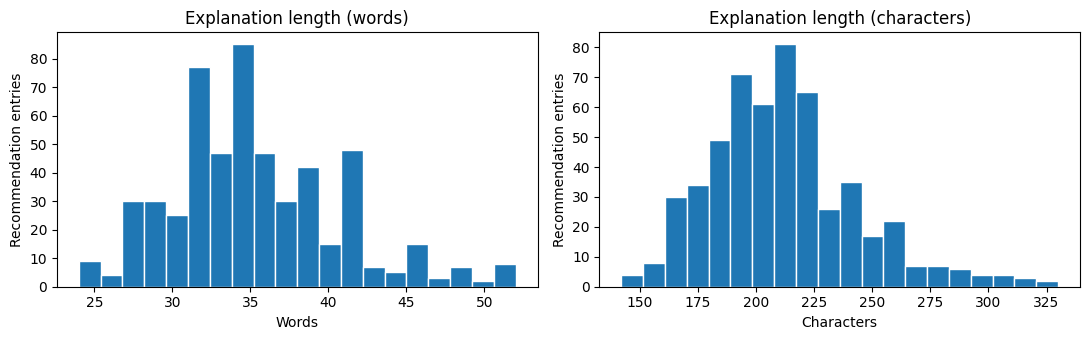

In [33]:
# plot

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, column, label in zip(axes, ["word_count", "character_count"], ["Words", "Characters"]):
    ax.hist(analysis_df[column], bins=20, edgecolor="white")
    ax.set(xlabel=label, ylabel="Recommendation entries", title=f"Explanation length ({label.lower()})")
plt.tight_layout()
plt.show()

### b-c Preprocessing for further analysis

 (Run ONLY Once, and store the result for future use)

In [34]:
%pip install -q spacy pyarrow
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


compose records for recommendation explanations, recipes and personas (raw text for now).

In [35]:
import re
import unicodedata
from pathlib import Path

import pandas as pd
import spacy

def normalize_text(value):
    """Normalize Unicode and spacing before tokenization."""
    if value is None: # None
        return ""

    if not isinstance(value, str):
        try:
            if pd.isna(value): # NA
                return ""
        except (TypeError, ValueError):
            pass
        value = str(value)

    # unify Unicode char
    value = unicodedata.normalize("NFKC", value)
    value = (
        value.replace("’", "'")
        .replace("‘", "'")
        .replace("“", '"')
        .replace("”", '"')
        .replace("–", "-")
        .replace("—", "-")
    )

    # cope with spaces
    return re.sub(r"\s+", " ", value).strip()

def add_text_items(
    records,
    entity_id,
    source_field,
    value,
    lemma_column,
    keep_numbers,
    persona_id=None,
    recipe_id=None,
    rank=None,
    recommendation_id=None,
    remove_ingredient_quantities=False
):
    """Add one row per text item, such as one ingredient or tag."""
    if isinstance(value, (list, tuple)):
        items = list(enumerate(value))
    else:
        items = [(0, value)]

    for item_index, item in items:
        text = normalize_text(item)
        if not text:
            continue

        records.append({
            "document_id": (
                f"{entity_id}:{source_field}:{item_index}"
            ),
            "recommendation_id": recommendation_id,
            "persona_id": persona_id,
            "recipe_id": recipe_id,
            "rank": rank,
            "source_field": source_field,
            "item_index": item_index,
            "_text": text,
            "_lemma_column": lemma_column,
            "_keep_numbers": keep_numbers,
            "_remove_ingredient_quantities":
                remove_ingredient_quantities
        })

# make records for explanations, recipes, and personas ############

# One explanation row per recommendation.
explanation_records = []

for item in recommendations:
    persona_id = str(item["persona"]["id"])

    for rank, recommendation in enumerate(
        item["recommendations"],
        start=1
    ):
        recipe_id = str(recommendation["recipe_id"])
        recommendation_id = f"{persona_id}_rank_{rank:02d}"

        add_text_items(
            explanation_records,
            entity_id=recommendation_id,
            source_field="explanation", # register
            value=recommendation["explanation"], # explanation text
            lemma_column="explanation_lemmas", # specify column name where stores lemmas
            keep_numbers=True,
            persona_id=persona_id, # who's recommendation is this
            recipe_id=recipe_id, # recommended recipe's id
            rank=rank, # the recommendation rank
            recommendation_id=recommendation_id
        )

# Recipe titles, ingredients, and tags.
recipe_records = []

# generate records for parts of recipes separately
for _, row in recipes.drop_duplicates("recipe_id").iterrows():
    recipe_id = str(row["recipe_id"])

    # recipe title as record
    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_title",
        value=row["title"],
        lemma_column="recipe_text_lemmas", # specify column name where stores lemmas
        keep_numbers=True,
        recipe_id=recipe_id
    )

    # recipe ingredient as record
    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_ingredient",
        value=row["ingredients_title"],
        lemma_column="recipe_text_lemmas", # specify column name where stores lemmas
        keep_numbers=False,
        recipe_id=recipe_id,
        remove_ingredient_quantities=True
    )

    # recipe tags as record
    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_tag",
        value=row["tags"],
        lemma_column="recipe_text_lemmas", # specify column name where stores lemmas
        keep_numbers=True,
        recipe_id=recipe_id
    )



# Persona descriptions, goals, preferences, restrictions, allergies,
# and health conditions.
persona_records = []

persona_fields = {
    "description": "persona_description",
    "profile.dietary_goal": "dietary_goal",
    "profile.dietaryProfile.dietaryRestrictions.selected":
        "dietary_restriction",
    "profile.dietaryProfile.dietaryRestrictions.other":
        "dietary_restriction_other",
    "profile.dietaryProfile.foodAllergies.selected":
        "food_allergy",
    "profile.dietaryProfile.foodAllergies.other":
        "food_allergy_other",
    "profile.dietaryProfile.healthConditions.selected":
        "health_condition",
    "profile.dietaryProfile.healthConditions.other":
        "health_condition_other",
    "profile.likedIngredients": "liked_ingredient",
    "profile.dislikedIngredients": "disliked_ingredient",
    "profile.favoriteCuisines": "favorite_cuisine"
}

for _, row in personas_df.iterrows():
    persona_id = str(row["id"])

    for column, source_field in persona_fields.items():
        add_text_items(
            persona_records,
            entity_id=persona_id,
            source_field=source_field,
            value=row[column],
            lemma_column="persona_text_lemmas",
            keep_numbers=True,
            persona_id=persona_id
        )


compose lemmatized text of the former records

In [36]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

# Keep these words even when spaCy marks them as stopwords.
keep_stopwords = {
    # Negation
    "no", "not", "never", "neither", "nor", "without",
    "hardly", "barely", "rarely",

    # References to the user or item
    "you", "your", "yours", "yourself", "yourselves",
    "this", "that", "these", "those", "it",
    "they", "them", "their", "its",

    # Degree and quantity
    "very", "too", "enough", "more", "most", "less", "least",
    "extremely", "highly", "slightly", "moderately",
    "relatively", "especially", "particularly", "quite",
    "rather", "much", "many", "few", "little",
    "high", "low", "higher", "lower",

    # Modality and uncertainty
    "can", "could", "may", "might", "must", "should",
    "would", "possibly", "perhaps"
}


# Remove these from recipe ingredient text because they usually
# describe quantity or package size rather than the ingredient.
ingredient_quantity_terms = {
    "piece", "serving", "cup", "teaspoon", "tablespoon",
    "ounce", "pound", "gram", "kilogram", "milliliter",
    "liter", "package", "slice", "pinch", "dash"
}

# Standardize common units before joining them to numeric values.
unit_forms = {
    "gram": "g",
    "grams": "g",
    "milligram": "mg",
    "milligrams": "mg",
    "microgram": "mcg",
    "micrograms": "mcg",
    "kilogram": "kg",
    "kilograms": "kg",
    "milliliter": "ml",
    "milliliters": "ml",
    "liter": "l",
    "liters": "l",
    "ounce": "oz",
    "ounces": "oz",
    "pound": "lb",
    "pounds": "lb",
    "g": "g",
    "mg": "mg",
    "ml": "ml"
}


def is_number(value):
    """Check whether a token is a whole or decimal number."""
    return bool(re.fullmatch(r"\d+(?:\.\d+)?", value))


def combine_numbers_and_units(lemmas):
    """
    Combine values such as ['15', 'g'] into ['15g'].
    Combine type labels such as ['type', '1'] into ['type-1'].
    """
    combined = []
    i = 0

    while i < len(lemmas):
        current = lemmas[i]

        # Keep medical subtype expressions together.
        if (
            current == "type"
            and i + 1 < len(lemmas)
            and is_number(lemmas[i + 1])
        ):
            combined.append(f"type-{lemmas[i + 1]}")
            i += 2
            continue

        # Combine a number with a recognized measurement unit.
        if (
            is_number(current)
            and i + 1 < len(lemmas)
            and lemmas[i + 1] in unit_forms
        ):
            combined.append(
                current + unit_forms[lemmas[i + 1]]
            )
            i += 2
            continue

        # Keep percentage values together.
        if (
            is_number(current)
            and i + 1 < len(lemmas)
            and lemmas[i + 1] == "%"
        ):
            combined.append(current + "%")
            i += 2
            continue

        combined.append(current)
        i += 1

    return combined


def lemmatize_doc(
    doc,
    keep_numbers,
    remove_ingredient_quantities=False
):
    """Remove punctuation and ordinary stopwords, then lemmatize."""
    lemmas = []

    for token in doc:
        if token.is_space:
            continue

        # Handle percent before punctuation filtering.
        if token.text == "%":
            if keep_numbers:
                lemmas.append("%")
            continue

        # Keep numbers in explanations and persona text.
        if token.like_num:
            if keep_numbers:
                lemmas.append(token.text.lower())
            continue

        # Remove brackets, commas, hyphens, and other punctuation.
        if token.is_punct:
            continue

        surface = token.lower_

        # spaCy splits contractions such as "isn't" into "is" and "n't".
        if surface in {"n't", "n’t"}:
            lemmas.append("not")
            continue

        lemma = token.lemma_.lower().strip()
        if not lemma or lemma == "-pron-":
            lemma = surface

        # Keep alphanumeric names such as B12, even when recipe quantities
        # are removed.
        has_letters = any(character.isalpha() for character in token.text)
        has_digits = any(character.isdigit() for character in token.text)
        is_alphanumeric_name = has_letters and has_digits

        if (
            remove_ingredient_quantities
            and lemma in ingredient_quantity_terms
        ):
            continue

        if token.is_stop and lemma not in keep_stopwords:
            continue

        if token.is_alpha or is_alphanumeric_name or lemma in keep_stopwords:
            lemmas.append(lemma)

    return combine_numbers_and_units(lemmas)


def make_lemma_table(records):
    """Save IDs, source field, and named lemma column; omit source text."""

    # get all explanations as texts.
    texts = [record["_text"] for record in records]

    docs = nlp.pipe(texts, batch_size=64)

    rows = []

    # combine record meta data and text processed data
    for record, doc in zip(records, docs):
        lemma_column = record["_lemma_column"] # get the name of lemma-column

        rows.append({
            "document_id": record["document_id"],
            "recommendation_id": record["recommendation_id"],
            "persona_id": record["persona_id"],
            "recipe_id": record["recipe_id"],
            "rank": record["rank"],
            "source_field": record["source_field"],
            "item_index": record["item_index"],
            lemma_column: lemmatize_doc( # processed text
                doc,
                keep_numbers=record["_keep_numbers"],
                remove_ingredient_quantities=(
                    record["_remove_ingredient_quantities"]
                )
            )
        })

    return pd.DataFrame(rows)


explanation_lemmas_df = make_lemma_table(explanation_records)
recipe_lemmas_df = make_lemma_table(recipe_records)
persona_lemmas_df = make_lemma_table(persona_records)

explanation_lemmas_df["rank"] = (
    explanation_lemmas_df["rank"].astype("Int64")
)

assert explanation_lemmas_df["recommendation_id"].is_unique
assert len(explanation_lemmas_df) == len(recommendations_df)

save results for future use

In [37]:
# store the processed text for future use
processed_dir = Path(
    "/content/drive/MyDrive/XFoodRec_Project_Data/processed"
)
processed_dir.mkdir(parents=True, exist_ok=True)


explanation_lemmas_df.to_parquet(
    processed_dir / "explanation_lemmas.parquet",
    index=False
)
recipe_lemmas_df.to_parquet(
    processed_dir / "recipe_lemmas.parquet",
    index=False
)
persona_lemmas_df.to_parquet(
    processed_dir / "persona_lemmas.parquet",
    index=False
)

print("Saved processed files to:", processed_dir)
print("Explanation records:", len(explanation_lemmas_df))
print("Recipe text items:", len(recipe_lemmas_df))
print("Persona text items:", len(persona_lemmas_df))

display(
    explanation_lemmas_df[
        [
            "recommendation_id",
            "persona_id",
            "recipe_id",
            "rank",
            "explanation_lemmas"
        ]
    ].head()
)

display(
    recipe_lemmas_df.loc[
        recipe_lemmas_df["source_field"].eq("recipe_ingredient"),
        ["recipe_id", "recipe_text_lemmas"]
    ].head()
)

Saved processed files to: /content/drive/MyDrive/XFoodRec_Project_Data/processed
Explanation records: 536
Recipe text items: 2106
Persona text items: 530


,recommendation_id,persona_id,recipe_id,rank,explanation_lemmas
0,user_01_rank_01,user_01,81968,1,"[chickpea, spinach, greek, fantastic, choice, ..."
1,user_01_rank_02,user_01,10614,2,"[refried, beans, offer, high, protein, content..."
2,user_01_rank_03,user_01,94673,3,"[egyptian, red, lentil, soup, rich, protein, f..."
3,user_01_rank_04,user_01,364252,4,"[favorite, sauteed, kale, nutrient, dense, opt..."
4,user_01_rank_05,user_01,12569,5,"[hearty, black, beans, rice, combine, protein,..."


,recipe_id,recipe_text_lemmas
1,113861,"[cub, steak, oil, butter, flour, salt, onion, ..."
4,111212,"[lea, perrins, worcestershire, sauce, lea, per..."
7,497021,"[lean, beef, coleslaw, mix, cabbage, carrot, s..."
10,31184,"[extra, virgin, olive, oil, onion, clove, garl..."
13,71739,"[olive, oil, onion, garlic, clove, long, grain..."


### Load processed data (DO this to CONTINUE analysis no need run ALL cells)

In [38]:
processed_dir = Path("/content/drive/MyDrive/XFoodRec_Project_Data/processed")

recommendation_tokens_df = pd.read_parquet(processed_dir / "recommendation_tokens.parquet")
recipe_tokens_df = pd.read_parquet(processed_dir / "recipe_tokens.parquet")
persona_tokens_df = pd.read_parquet(processed_dir / "persona_tokens.parquet")
explanation_lemmas_df = pd.read_parquet(processed_dir / "explanation_lemmas.parquet")
recipe_lemmas_df = pd.read_parquet(processed_dir / "recipe_lemmas.parquet")
persona_lemmas_df = pd.read_parquet(processed_dir / "persona_lemmas.parquet")
nutrition_fields_path = processed_dir / "nutrition_fields.json"

print("Explanations:", len(recommendation_tokens_df))
print("Recipe text items:", len(recipe_tokens_df))
print("Persona text items:", len(persona_tokens_df))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/XFoodRec_Project_Data/processed/recommendation_tokens.parquet'

These files contain reusable processed text data. Parquet files store tables; the attributes below describe what each table contains and how it can be used.

| File | Key and linking attributes | Text attributes | Use |
|---|---|---|---|
| `recommendation_tokens.parquet` | `recommendation_id`, `persona_id`, `recipe_id`, `rank` | Tokenized recommendation text | Analyze recommendation text at the token level. |
| `recipe_tokens.parquet` | `recipe_id`, `source_field` | Tokenized recipe text | Analyze recipe text. Use `source_field` to identify which recipe field the text came from. |
| `persona_tokens.parquet` | `persona_id`, `source_field` | Tokenized persona text | Analyze persona descriptions and preferences. Use `source_field` to identify which persona field the text came from. |
| `explanation_lemmas.parquet` | `recommendation_id`, `persona_id`, `recipe_id`, `rank` | `explanation_lemmas` | Analyze explanation wording using normalized word forms. |
| `recipe_lemmas.parquet` | `recipe_id`, `source_field` | `recipe_text_lemmas` | Match explanation terms with recipe titles, ingredients, or other recipe fields. |
| `persona_lemmas.parquet` | `persona_id`, `source_field` | `persona_text_lemmas` | Match explanation terms with persona goals, preferences, and restrictions. |
| `nutrition_fields.json` | Not row-based; contains nutrition field names | For example: `calories`, `protein`, `carbs`, `fat` | Supplies the nutrition field names used by the analysis code. |

`recommendation_id` identifies one recommendation and its explanation. Use `recipe_id` to link recommendation data to recipe data, and `persona_id` to link it to persona data. `rank` records the recommendation's position for that persona.

Token files store tokenized text. Lemma files store lemmatized text.

The exact token-text column names may differ between files. Check each DataFrame's columns before using them.

### Shared matching helpers
(used by 1.2d and Task 2)

Tools for finding, in an explanation, things that exist in the data. They are built once from the persona and recipe data only, so explanations from every model are processed in exactly the same way.

| Name | What it gives |
|---|---|
| `explanation_words(row, matching_resources)` | The words of one explanation (a row of `explanation_lemmas_df`), in base form, with the recipe title removed |
| `matching_resources["persona_values"]` | Each persona's own values by field: liked / disliked ingredients (core noun phrase, e.g. "frozen vegetables" -> "vegetable"), favourite cuisines, goal, diets, allergies, health conditions |
| `matching_resources["health_label_values"]` | Goals, diets and health conditions of all personas, except values that are also someone's taste item (e.g. "mediterranean") |
| `matching_resources["nutrient_terms"]` | Nutrients recorded in the recipe data (from the nutrient columns and `nutrition_fields.json`) |
| `matching_resources["ingredient_names"]` | Each recipe's ingredient names: the main noun phrase of every ingredient line (e.g. "cubed steak (4-6 pieces)" -> "steak") |
| `matching_resources["food_terms"]` | All food words: every recipe's ingredient names plus the personas' liked and disliked ingredients |
| `noun_phrase_core(chunk)` | The main noun of a spaCy noun phrase with the words that name it (e.g. "olive oil", "baking mix"); describing words are dropped ("frozen vegetables" -> "vegetable") |
| `contains_sequence(terms, value)` | Whether a multi-word value appears in the explanation words |
| `term_matches(word, term)` | Whether two words match: identical, or sharing a beginning of at least `MIN_PREFIX_LENGTH` letters ("sugar" / "sugary") |

Rules:

- Words are compared in base form ("oats" and "oat", "potatoes" and "potato" are the same).
- The recipe title is removed first, so words that only appear in the title are not counted.
- In ingredient lines, notes in brackets are skipped (also when a note is split over two lines), lines that continue the previous one ("and ...") are skipped, and a word that takes an object ("use salted butter") is read as a verb.
- No word lists are written by hand; every value comes from the data.
- Later cells should not reuse these names for other variables (a variable named `explanation_words` would replace the function).

In [ ]:
import re

import spacy

# Persona fields: the taste profile and the dietary needs.
TASTE_FIELDS = ["liked_ingredient", "disliked_ingredient", "favorite_cuisine"]
HEALTH_FIELDS = ["dietary_goal", "dietary_restriction", "food_allergy", "health_condition"]
# Ingredients are matched by their core noun phrase; cuisines and health values are matched as written.
NOUN_PHRASE_FIELDS = ["liked_ingredient", "disliked_ingredient"]
# Allergens are foods ("egg", "milk"), so they are not general health labels.
NOT_A_LABEL_FIELDS = ["food_allergy"]

MIN_PREFIX_LENGTH = 4  # word forms sharing a beginning match, e.g. "sugar" / "sugary"

text_nlp = spacy.load("en_core_web_sm", disable=["ner"])
# spaCy adds every processed string to its vocabulary, so keep the model's own word list as loaded.
SPACY_MODEL_WORDS = set(text_nlp.vocab.strings)
_base_forms = {}


def to_list(value):
    if isinstance(value, np.ndarray):
        value = value.tolist()
    return [str(v).lower() for v in value] if isinstance(value, (list, tuple)) else []


def base_forms(tokens):
    """spaCy lemma of each word on its own, so 'oats'/'oat' and 'potatoes'/'potato' align."""
    new = sorted({t for t in tokens if t not in _base_forms})
    for word, doc in zip(new, text_nlp.pipe(new)):
        _base_forms[word] = doc[0].lemma_.lower() if len(doc) else word
    return [_base_forms[t] for t in tokens]


def term_matches(token, term):
    shorter, longer = sorted((token, term), key=len)
    return token == term or (len(shorter) >= MIN_PREFIX_LENGTH and longer.startswith(shorter))


def contains_sequence(tokens, sequence):
    n = len(sequence)
    return n > 0 and any(tokens[i:i + n] == sequence for i in range(len(tokens) - n + 1))


def item_key(lemmas):
    """Core noun phrase of a persona item: 'oats certify gf' -> 'oat', 'frozen vegetable' -> 'vegetable'."""
    doc = text_nlp(" ".join(lemmas))
    chunks = list(doc.noun_chunks)
    if not chunks:
        return base_forms(lemmas)
    root = chunks[0].root
    words = [t.text for t in chunks[0] if t.i == root.i or (t.dep_ == "compound" and t.head.i == root.i)]
    return base_forms(words)


def remove_title(tokens, title):
    """Drop every occurrence of the recipe title, then an opening run of title words or stop words."""
    kept, i, n = [], 0, len(title)
    while i < len(tokens):
        if n and tokens[i:i + n] == title:
            i += n
        else:
            kept.append(tokens[i])
            i += 1
    title_words, start = set(title), 0
    while start < min(len(kept), n + 2) and (kept[start] in title_words or kept[start] in text_nlp.Defaults.stop_words):
        start += 1
    return kept[start:]


def nutrient_terms_from_data(recipe_columns, nutrition_fields):
    """Nutrients recorded in the data: the recipe nutrient columns ('dietaryfiber_per_serving [g]'
    -> 'fiber') and nutrition_fields.json. Compound column names keep their longest ending that is
    an English word in spaCy's vocabulary."""
    terms = {str(f).lower() for f in nutrition_fields}
    for column in recipe_columns:
        name = re.sub(r"\[[^\]]*\]", "", str(column).lower()).strip()
        if "_per_" not in name:
            continue
        word = name.split("_per_")[0]
        endings = [word[i:] for i in range(len(word)) if word[i:] in SPACY_MODEL_WORDS]
        terms.add(max(endings, key=len) if endings else word)
    return sorted(set(base_forms(sorted(terms))))


def noun_phrase_core(chunk, is_name=False):
    """Main noun of a spaCy noun phrase with the words that name it: compounds and -ing words
    ('olive oil', 'baking mix'); describing words are dropped ('frozen vegetables' -> 'vegetable').
    For ingredient names (is_name=True) an -ing word right before the phrase also belongs to it."""
    root = chunk.root
    words = [t for t in chunk if t.i == root.i or (t.head.i == root.i and (t.dep_ == "compound" or t.tag_ == "VBG"))]
    before, after = chunk.start - 1, chunk.end
    if is_name and before >= 0 and chunk.doc[before].tag_ == "VBG" and chunk.doc[before] not in words:
        words = [chunk.doc[before]] + words
    if is_name and after < len(chunk.doc) and chunk.doc[after].tag_ == "VBG" and chunk.doc[after].head.i == root.i:
        words = words + [chunk.doc[after]]  # "salad dressing" when spaCy reads "dressing" as a verb
    terms = base_forms([t.text.lower() for t in words])
    return [] if all(t in text_nlp.Defaults.stop_words for t in terms) else terms


def clean_ingredient_line(line):
    """Drop notes in brackets, including a note that started on the previous line ('in this recipe)')."""
    line = str(line).lower()
    if ")" in line and ("(" not in line or line.index(")") < line.index("(")):
        line = line[line.index(")") + 1:]
    return re.sub(r"\([^)]*\)?", " ", line).strip()


def ingredient_line_names(doc):
    """Ingredient names in one parsed ingredient line: its main noun phrase and phrases joined to it by
    'and' / 'or'. A line that continues the previous one (starts with 'and' / 'or') gives nothing, and a
    'noun' that takes an object ('use salted butter') is read as a verb."""
    if len(doc) and doc[0].pos_ == "CCONJ":
        return []
    chunks = [c for c in doc.noun_chunks if not any(child.dep_ == "dobj" for child in c.root.children)]
    if not chunks:  # a bare name that spaCy does not parse as a noun phrase, e.g. "tahini"
        terms = base_forms([t.text.lower() for t in doc if not (t.is_punct or t.is_space or t.like_num)])
        return [terms] if terms and not all(t in text_nlp.Defaults.stop_words for t in terms) else []
    main = [c for c in chunks
            if c.root.dep_ == "ROOT" or (c.root.head.dep_ == "ROOT" and c.root.dep_ in ("dobj", "compound"))]
    main = main or chunks[:1]
    for c in chunks:
        if c not in main and c.root.dep_ == "conj" and any(c.root.head.i == m.root.i for m in main):
            main.append(c)
    return [name for name in (noun_phrase_core(c, is_name=True) for c in main) if name]


def build_matching_resources(persona_lemmas_df, recipe_lemmas_df, recipe_table, nutrition_fields):
    persona_values = {}
    for row in persona_lemmas_df.to_dict("records"):
        field = row["source_field"]
        if field not in TASTE_FIELDS + HEALTH_FIELDS:
            continue
        lemmas = to_list(row["persona_text_lemmas"])
        terms = item_key(lemmas) if field in NOUN_PHRASE_FIELDS else base_forms(lemmas)
        if terms:
            persona_values.setdefault(str(row["persona_id"]), []).append((field, terms))

    taste_values = {tuple(t) for values in persona_values.values() for f, t in values if f in TASTE_FIELDS}
    health_label_values = sorted({
        tuple(t) for values in persona_values.values() for f, t in values
        if f in HEALTH_FIELDS and f not in NOT_A_LABEL_FIELDS and tuple(t) not in taste_values
    })
    titles = {
        str(row["recipe_id"]): base_forms(to_list(row["recipe_text_lemmas"]))
        for row in recipe_lemmas_df.to_dict("records") if row["source_field"] == "recipe_title"
    }

    line_recipes, line_texts = [], []
    for recipe_id, lines in zip(recipe_table["recipe_id"].astype(str), recipe_table["ingredients_title"]):
        for line in to_list(lines):
            line_recipes.append(recipe_id)
            line_texts.append(clean_ingredient_line(line))
    ingredient_names = {}
    for recipe_id, doc in zip(line_recipes, text_nlp.pipe(line_texts, batch_size=256)):
        for name in ingredient_line_names(doc):
            ingredient_names.setdefault(recipe_id, set()).add(tuple(name))
    # Food words are names used as ingredients in the recipe data. Persona likes / dislikes are not added:
    # they also hold dish types and habits ("desserts", "complicated recipes").
    food_terms = set().union(*ingredient_names.values())
    return {
        "persona_values": persona_values,
        "health_label_values": [list(v) for v in health_label_values],
        "titles": titles,
        "nutrient_terms": nutrient_terms_from_data(list(recipe_table.columns), nutrition_fields),
        "ingredient_names": ingredient_names,
        "food_terms": food_terms,
    }


def explanation_words(row, resources):
    """Words of one explanation (a row of explanation_lemmas_df), in base form, title removed."""
    terms = base_forms(to_list(row["explanation_lemmas"]))
    return remove_title(terms, resources["titles"].get(str(row["recipe_id"]), []))


recipe_table = recipes if "recipes" in globals() else pd.read_parquet(recipe_path)
with open(nutrition_fields_path, "r", encoding="utf-8") as f:
    nutrition_fields = json.load(f)
matching_resources = build_matching_resources(persona_lemmas_df, recipe_lemmas_df, recipe_table, nutrition_fields)
print("Nutrients recorded in the data:", matching_resources["nutrient_terms"])
print("Health label values (goals, diets, conditions):", len(matching_resources["health_label_values"]))
print("Personas with values:", len(matching_resources["persona_values"]))
print("Recipes with ingredient names:", len(matching_resources["ingredient_names"]),
      "| food words:", len(matching_resources["food_terms"]))

### c. Distribution of explanation types (ingredient-, nutrition-, taste-focused)

In [ ]:
import ast
from matplotlib.colors import to_hex, to_rgb
from matplotlib.patches import Patch

def as_lemma_list(value):
    if hasattr(value, "as_py"):
        value = value.as_py()
    elif isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, (list, tuple)):
        return [
            str(item).strip().lower()
            for item in value
            if item is not None and str(item).strip()
        ]

    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple)):
                return [
                    str(item).strip().lower()
                    for item in parsed
                    if item is not None and str(item).strip()
                ]
        except (ValueError, SyntaxError):
            pass

    return []


# nutrition field names
if "nutrition_df" in globals():
    nutrition_columns = list(nutrition_df.columns)

    with open(nutrition_fields_path, "w", encoding="utf-8") as f:
        json.dump(nutrition_columns, f, ensure_ascii=False, indent=2)

elif nutrition_fields_path.exists():
    with open(nutrition_fields_path, "r", encoding="utf-8") as f:
        nutrition_columns = json.load(f)

elif "recipes" in globals():
    nutrition_columns = [
        column
        for column in recipes.columns
        if "_per_serving" in str(column).lower()
        or "_per_100g" in str(column).lower()
    ]

else:
    raise FileNotFoundError(
        "Nutrition field names are unavailable. "
        "Run the data-loading cells once so they can be saved."
    )


def derive_nutrition_terms(columns):
    """Derive nutrient words from nutrition field names."""
    aliases = {
        "calories": "calorie",
        "carbs": "carb",
        "carbohydrates": "carbohydrate",
        "fats": "fat",
        "sugars": "sugar",
        "fibre": "fiber",
        "fibres": "fiber",
        "proteins": "protein",
        "totalfat": "fat",
        "saturatedfat": "fat",
        "totalcarbohydrate": "carbohydrate",
        "dietaryfiber": "fiber",
        "caloriesfromfat": "calorie"
    }

    terms = set()

    for column in columns:
        name = str(column).lower()
        name = re.sub(r"\[[^\]]*\]", " ", name)
        name = re.sub(r"_per_(serving|100g)", " ", name)

        # split common combined nutrient names
        name = name.replace("caloriesfromfat", "calories fat")
        name = name.replace("totalcarbohydrate", "carbohydrate")
        name = name.replace("dietaryfiber", "fiber")
        name = name.replace("saturatedfat", "fat")
        name = name.replace("totalfat", "fat")

        for word in re.findall(r"[a-z]+", name):
            term = aliases.get(word, word)

            if term not in {
                "per", "serving", "cal", "g", "mg"
            }:
                terms.add(term)
    terms.update({"nutrition", "nutrient", "nutritious"})

    return terms


nutrition_terms = derive_nutrition_terms(nutrition_columns)

taste_terms = {
    "taste", "flavor", "flavour", "delicious", "tasty",
    "savory", "savoury", "sweet", "spicy", "tangy",
    "creamy", "crunchy", "crispy", "tender", "juicy",
    "aromatic", "refreshing", "hearty", "satisfy",
    "comfort", "warm", "mild", "bitter", "sour", "smoky",
    "texture"
}

# occur in ingredient descriptions, but are not ingredients.
ingredient_noise_terms = {
    "taste", "your", "favorite", "favourite", "optional",
    "needed", "desired", "garnish", "serve", "serving",
    "adjust", "approximately"
}


ingredients_by_recipe = {}
titles_by_recipe = {}

for row in recipe_lemmas_df.to_dict("records"):
    recipe_id = str(row["recipe_id"])
    source_field = row["source_field"]
    lemmas = as_lemma_list(row["recipe_text_lemmas"])

    if source_field == "recipe_ingredient":
        clean_ingredients = {
            lemma
            for lemma in lemmas
            if lemma not in ingredient_noise_terms
        }
        ingredients_by_recipe.setdefault(recipe_id, set()).update(
            clean_ingredients
        )

    elif source_field == "recipe_title":
        titles_by_recipe[recipe_id] = lemmas


def remove_leading_title(explanation_lemmas, title_lemmas):
    """Ignore the recipe title when it appears at the start."""
    if (
        title_lemmas
        and explanation_lemmas[:len(title_lemmas)] == title_lemmas
    ):
        return explanation_lemmas[len(title_lemmas):]

    return explanation_lemmas


# match each explanation to focus vocabularies
analysis_df = explanation_lemmas_df.copy()

ingredient_matches = []
nutrition_matches = []
taste_matches = []

for row in analysis_df.to_dict("records"):
    recipe_id = str(row["recipe_id"])
    explanation = as_lemma_list(row["explanation_lemmas"])

    explanation_body = remove_leading_title(
        explanation,
        titles_by_recipe.get(recipe_id, [])
    )

    recipe_ingredients = ingredients_by_recipe.get(recipe_id, set())
    explanation_terms = set(explanation_body)

    ingredient_matches.append(
        sorted(explanation_terms & recipe_ingredients)
    )
    nutrition_matches.append(
        sorted(explanation_terms & nutrition_terms)
    )
    taste_matches.append(
        sorted(explanation_terms & taste_terms)
    )

analysis_df["ingredient_matches"] = ingredient_matches
analysis_df["nutrition_matches"] = nutrition_matches
analysis_df["taste_matches"] = taste_matches

analysis_df["ingredient_focused"] = analysis_df["ingredient_matches"].map(bool)
analysis_df["nutrition_focused"] = analysis_df["nutrition_matches"].map(bool)
analysis_df["taste_focused"] = analysis_df["taste_matches"].map(bool)

focus_columns = [
    "ingredient_focused",
    "nutrition_focused",
    "taste_focused"
]
focus_labels = {
    "ingredient_focused": "Ingredient",
    "nutrition_focused": "Nutrition",
    "taste_focused": "Taste"
}

total_explanations = len(analysis_df)

if total_explanations == 0:
    raise ValueError("No explanation records were loaded.")

if not analysis_df[focus_columns].any(axis=None):
    raise ValueError(
        "No focus matches were found. Check the loaded lemmas and vocabularies."
    )


# summary by focus
type_summary = pd.DataFrame({
    "count": analysis_df[focus_columns].sum().astype(int),
    "percent": (
        analysis_df[focus_columns].mean().mul(100).round(1)
    )
})
type_summary.index = [
    focus_labels[column]
    for column in type_summary.index
]

display(type_summary)


def focus_combination(row):
    labels = [
        focus_labels[column]
        for column in focus_columns
        if row[column]
    ]
    return " + ".join(labels) if labels else "No detected focus"


analysis_df["focus_combination"] = analysis_df.apply(
    focus_combination,
    axis=1
)

combination_summary = (
    analysis_df["focus_combination"]
    .value_counts()
    .rename_axis("focus_combination")
    .to_frame("count")
)
combination_summary["percent"] = (
    combination_summary["count"]
    .div(total_explanations)
    .mul(100)
    .round(1)
)

display(combination_summary)


focus_colors = {
    "Ingredient": "#E76F51",
    "Nutrition": "#2A9D8F",
    "Taste": "#E9C46A"
}


def color_for_combination(combination):
    if combination == "No detected focus":
        return "#B8B8B8"

    component_colors = [
        to_rgb(focus_colors[label])
        for label in combination.split(" + ")
    ]

    mixed_color = tuple(
        sum(color[channel] for color in component_colors)
        / len(component_colors)
        for channel in range(3)
    )
    return to_hex(mixed_color)


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [0.8, 1.5]}
)

# total count in each focus category.
left_labels = ["Ingredient", "Nutrition", "Taste"]
left_counts = [
    int(analysis_df[column].sum())
    for column in focus_columns
]

bars = axes[0].bar(
    left_labels,
    left_counts,
    color=[focus_colors[label] for label in left_labels]
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Explanations by focus")
axes[0].set_ylabel("Number of explanations")
axes[0].set_ylim(0, max(left_counts) * 1.15)
axes[0].tick_params(axis="x", rotation=15)

# exact combinations, using mixed colors for combined focuses.
plot_data = combination_summary.sort_values("count")
combination_labels = plot_data.index.tolist()
combination_counts = plot_data["count"].tolist()

bars = axes[1].barh(
    combination_labels,
    combination_counts,
    color=[
        color_for_combination(label)
        for label in combination_labels
    ]
)
axes[1].bar_label(bars, padding=3)
axes[1].set_title("Exact focus combinations")
axes[1].set_xlabel("Number of explanations")
axes[1].set_xlim(0, max(combination_counts) * 1.2)

axes[1].legend(
    handles=[
        Patch(facecolor=color, label=label)
        for label, color in focus_colors.items()
    ],
    title="Focus colors",
    loc="lower right"
)

fig.suptitle(
    f"Explanation focus distribution (n={total_explanations})"
)
plt.tight_layout()
plt.show()


# Inspect matches to confirm that ingredient noise terms are gone.
display(
    analysis_df[
        [
            "recommendation_id",
            "ingredient_matches",
            "nutrition_matches",
            "taste_matches",
            "focus_combination"
        ]
    ].head(15)
)

### d. Coverage of user preferences vs. health justification

Each explanation is checked for two things: whether it refers to the user's preferences, and whether it gives a health justification. One explanation can count as both, one, or neither. Only things that exist in the data count.

| What the explanation mentions | Counted as |
|---|---|
| The user's own liked or disliked ingredients or favourite cuisines (e.g. "lentils, which you enjoy", or "features chicken" for a user who likes chicken) | Preference |
| A nutrient recorded in the recipe data, with or without numbers (e.g. "high in protein", "33.1 g of protein", "low in sodium") | Health |
| A goal, diet or health condition from the user profiles (e.g. "weight loss", "vegan", "low sodium") | Health |
| An allergen, only for the user who has that allergy | Health |
| General wording that names none of the above (e.g. "fits your preferences", "suits your dietary needs", "healthy") | Neither (left to the transparency analysis) |

The recipe title is removed from the explanation before matching, so words that only appear in the title are not counted.

In [ ]:
# Uses the shared matching helpers above (matching_resources, explanation_words, ...).


def find_user_factors(terms, persona_id, resources):
    """User factors mentioned in one explanation. Each mention has a group (preference, health,
    nutrition), whether it is this persona's own value (specific), and the evidence."""
    mentions = []
    for field, value in resources["persona_values"].get(persona_id, []):
        if contains_sequence(terms, value):
            group = "preference" if field in TASTE_FIELDS else "health"
            mentions.append({"group": group, "specific": True, "evidence": f"{field}: {' '.join(value)}"})
    for value in resources["health_label_values"]:
        if contains_sequence(terms, value):
            mentions.append({"group": "health", "specific": False, "evidence": " ".join(value)})
    for nutrient in resources["nutrient_terms"]:
        if any(term_matches(t, nutrient) for t in terms):
            mentions.append({"group": "nutrition", "specific": False, "evidence": nutrient})
    return mentions


def compute_coverage(explanation_lemmas_df, resources):
    """One row per explanation with the coverage flags and the evidence behind them."""
    rows = []
    for row in explanation_lemmas_df.to_dict("records"):
        mentions = find_user_factors(explanation_words(row, resources), str(row["persona_id"]), resources)

        def evidence(group):
            return sorted({m["evidence"] for m in mentions if m["group"] == group})

        rows.append({
            "recommendation_id": row["recommendation_id"],
            "user_factor_mentions": mentions,
            "preference_evidence": evidence("preference"),
            "health_evidence": evidence("health"),
            "nutrition_evidence": evidence("nutrition"),
        })
    coverage = pd.DataFrame(rows)
    coverage["preference_covered"] = coverage["preference_evidence"].map(bool)
    coverage["health_justification"] = coverage["health_evidence"].map(bool) | coverage["nutrition_evidence"].map(bool)
    coverage["coverage_group"] = np.select(
        [coverage["preference_covered"] & coverage["health_justification"],
         coverage["preference_covered"], coverage["health_justification"]],
        ["Both", "Preference only", "Health only"], default="Neither"
    )
    return coverage


coverage_df = compute_coverage(explanation_lemmas_df, matching_resources)

# Add the coverage columns to analysis_df (re-running this cell replaces them).
if "analysis_df" not in globals():
    analysis_df = explanation_lemmas_df.copy()
analysis_df = analysis_df.drop(
    columns=[c for c in coverage_df.columns if c != "recommendation_id" and c in analysis_df.columns]
).merge(coverage_df, on="recommendation_id", how="left", validate="one_to_one")

total = len(coverage_df)
coverage_order = ["Both", "Preference only", "Health only", "Neither"]
coverage_summary = (
    coverage_df["coverage_group"].value_counts().reindex(coverage_order, fill_value=0)
    .rename("count").to_frame()
)
coverage_summary["percent"] = (100 * coverage_summary["count"] / total).round(1)
display(coverage_summary)

evidence_summary = pd.DataFrame({
    "explanations": [
        coverage_df["preference_covered"].sum(),
        coverage_df["health_justification"].sum(),
        coverage_df["nutrition_evidence"].map(bool).sum(),
        coverage_df["health_evidence"].map(bool).sum(),
    ]
}, index=[
    "Preference: user's own ingredient or cuisine",
    "Health justification (any)",
    "  nutrient recorded in the recipe data",
    "  goal, diet, allergy or condition",
])
evidence_summary["percent"] = (100 * evidence_summary["explanations"] / total).round(1)
display(evidence_summary)

coverage_colors = {"Both": "#2A9D8F", "Preference only": "#E9C46A", "Health only": "#E76F51", "Neither": "#B8B8B8"}
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(coverage_order[::-1], coverage_summary["count"][coverage_order[::-1]],
               color=[coverage_colors[g] for g in coverage_order[::-1]])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of explanations")
ax.set_title(f"Coverage of user preferences vs. health justification (n={total})")
ax.set_xlim(0, coverage_summary["count"].max() * 1.15)
plt.tight_layout()
plt.show()

# 2. Entity Extraction, Fact Verification & Hallucination Detection

## 2.1. Extract three types of claims


In [ ]:
# Parse every explanation once; 2.1 a-c read their claims from these parses.
if "recommendations" not in globals():
    with open(recommendation_path, "r", encoding="utf-8") as f:
        recommendations = json.load(f)

# Same ids as the processed lemma table: "<persona id>_rank_<rank>".
claim_texts = {
    f"{entry['persona']['id']}_rank_{rank:02d}": rec["explanation"]
    for entry in recommendations
    for rank, rec in enumerate(entry["recommendations"], start=1)
}
assert set(claim_texts) == set(explanation_lemmas_df["recommendation_id"]), "ids differ from the lemma table"

claim_index = explanation_lemmas_df[["recommendation_id", "persona_id", "recipe_id", "rank"]].copy()
claim_ids = claim_index["recommendation_id"].tolist()
claim_docs = dict(zip(claim_ids, text_nlp.pipe([claim_texts[i] for i in claim_ids], batch_size=64)))

# Where the recipe title appears in each explanation (character spans), so claims inside it are skipped.
title_by_recipe = dict(zip(recipe_table["recipe_id"].astype(str), recipe_table["title"].astype(str).str.lower()))
claim_title_spans = {}
for row in claim_index.itertuples():
    title = title_by_recipe.get(str(row.recipe_id), "")
    text = claim_texts[row.recommendation_id].lower()
    claim_title_spans[row.recommendation_id] = [(m.start(), m.end()) for m in re.finditer(re.escape(title), text)] if title else []


def outside_title(span, recommendation_id):
    return not any(span.start_char < end and span.end_char > start for start, end in claim_title_spans[recommendation_id])


def sentence_number(span):
    return next(k for k, sentence in enumerate(span.doc.sents) if sentence.start <= span.start < sentence.end)


def is_negated(token):
    """spaCy's negation mark ('not', 'never') on the word or the words it hangs from, up to its verb,
    or the word being the object of 'without' ('without added sugars'). A 'not' with words of its own
    ('not only ... but also') does not negate."""
    chain = [token]
    while chain[-1].pos_ not in ("VERB", "AUX") and chain[-1].head.i != chain[-1].i:
        chain.append(chain[-1].head)
    return (any(child.dep_ == "neg" and not list(child.children) for t in chain for child in t.children)
            or any(t.dep_ == "prep" and t.lower_ == "without" for t in chain))


print("Explanations parsed:", len(claim_docs))
print("Explanations whose text contains the recipe title:", sum(bool(s) for s in claim_title_spans.values()))

### a. Ingredient mentions

In [ ]:
food_terms = matching_resources["food_terms"]

ingredient_claim_rows = []
for recommendation_id, doc in claim_docs.items():
    for chunk in doc.noun_chunks:
        if not outside_title(chunk, recommendation_id):
            continue
        # In "a mix of flavors" or "a variety of vegetables" the thing named comes after "of".
        if any(child.dep_ == "prep" and child.lower_ == "of" for child in chunk.root.children):
            continue
        core = noun_phrase_core(chunk)
        root = base_forms([chunk.root.text.lower()])
        if tuple(core) in food_terms:
            term = core
        elif tuple(root) in food_terms and root[0] not in text_nlp.Defaults.stop_words:
            term = root
        else:
            continue
        ingredient_claim_rows.append({
            "recommendation_id": recommendation_id,
            "claim_type": "ingredient",
            "sentence": sentence_number(chunk),
            "text": chunk.text,
            "term": " ".join(term),
            "negated": is_negated(chunk.root),
            "start_char": chunk.start_char,
            "end_char": chunk.end_char,
        })
ingredient_claims_df = pd.DataFrame(ingredient_claim_rows)

mentions_per_explanation = (
    ingredient_claims_df.groupby("recommendation_id").size()
    .reindex(claim_index["recommendation_id"], fill_value=0)
)
print(f"Ingredient mentions: {len(ingredient_claims_df)} in "
      f"{(mentions_per_explanation > 0).sum()} of {len(mentions_per_explanation)} explanations "
      f"({100 * (mentions_per_explanation > 0).mean():.1f}%)")
display(mentions_per_explanation.value_counts().sort_index().rename_axis("mentions in one explanation")
        .rename("explanations").to_frame())

top_ingredients = (
    ingredient_claims_df.groupby("term")
    .agg(mentions=("recommendation_id", "size"), explanations=("recommendation_id", "nunique"))
    .sort_values("mentions", ascending=False)
)
display(top_ingredients.head(15))

### b. Nutrient claims

Each claim keeps what the sentence says about it:

| Column | What it holds | Example |
|---|---|---|
| `number`, `unit` | An amount given for the nutrient | "33.1g of protein" → 33.1, g; "161 calories" → 161, calorie; "low in calories at 159.6" → 159.6 |
| `qualifier` | The describing word tied to the nutrient in the sentence | "high in protein" → high; "a good source of fiber" → good; "low-calorie" → low; "protein-packed" → packed |

A nutrient word with neither ("combines protein and fiber") is a plain mention. Nutrients joined by "and" share their wording: in "rich in protein and fiber" both are "rich". A number that the sentence structure does not tie to a nutrient belongs to the closest nutrient before it in the same sentence, if that nutrient has no number yet.

Nutrient words said about the user rather than the dish, i.e. in a phrase owned by "your" ("your low-carb diet", "your favorite proteins", "complements your protein-rich meals"), are not nutrient claims. When such a phrase names a user label ("low carb", "high protein") it is a label claim in c.

In [ ]:
nutrient_terms = matching_resources["nutrient_terms"]


def nutrient_name(word):
    """The recorded nutrient a word names ('carbs' -> 'carb', 'sugary' -> 'sugar'), or None."""
    base = base_forms([word.lower()])[0]
    names = [n for n in nutrient_terms if term_matches(base, n)]
    return base if base in names else next(iter(names), None)


def about_user(token):
    """The word sits in a phrase owned by the user ('your low-carb diet', 'your favorite proteins'):
    a second-person possessive on it or on the words it hangs from, up to its verb."""
    while True:
        if any(child.dep_ == "poss" and "2" in child.morph.get("Person") for child in token.children):
            return True
        if token.head.i == token.i or token.pos_ in ("VERB", "AUX"):
            return False
        token = token.head


def is_describing(token):
    """An adjective or past participle: 'high', 'lower', 'rich', 'packed'."""
    return token.tag_ in ("JJ", "JJR", "JJS", "VBN")


def is_amount(token):
    return bool(re.fullmatch(r"\d[\d,]*(\.\d+)?", token.text))


def words_in_front(noun):
    """Describing words placed before a noun: 'low' in 'low-calorie', 'good' in 'a good source'."""
    return [c for c in noun.children if c.dep_ == "amod" and c.i < noun.i and is_describing(c)]


def describing_word_of(prep):
    """The describing word a phrase like 'in calories' belongs to ('high in protein', 'packed with protein'):
    the closest one before it, also when spaCy hangs the phrase on the verb ('is low | in calories')."""
    governor = prep.head
    candidates = [governor] if is_describing(governor) else []
    candidates += [c for c in governor.children if c.dep_ in ("acomp", "attr", "conj") and is_describing(c)]
    return sorted((c for c in candidates if c.i < prep.i), key=lambda c: c.i)[-1:]


def read_nutrient_claim(token):
    """Describing words and amount (number, unit) of one nutrient word, from the spaCy parse."""
    qualifier, number, unit = words_in_front(token), None, None
    amounts = [c for c in token.children if c.dep_ == "nummod" and c.i < token.i and is_amount(c)]
    if amounts:  # "161 calories", "25g protein"
        number = amounts[0]
        units = [c for c in token.children if c.dep_ == "compound" and number.i < c.i < token.i]
        unit = units[0] if units else token
    # A nutrient joined by "and" to another one shares its wording: "rich in protein and fiber".
    anchor = token
    while anchor.dep_ == "conj" and anchor.head.is_alpha and nutrient_name(anchor.head.text):
        anchor = anchor.head
    if anchor is not token and not qualifier:  # "lower calories and fat"
        qualifier = words_in_front(anchor)
    holder = anchor.head
    if anchor.dep_ == "pobj" and holder.dep_ == "prep":
        qualifier += describing_word_of(holder)
        noun = holder.head
        if holder.lower_ == "of" and noun.pos_ in ("NOUN", "PROPN"):  # "a good source of protein", "21.4g of protein"
            qualifier += [] if qualifier else words_in_front(noun)
            counts = [c for c in noun.children if c.dep_ == "nummod" and is_amount(c)]
            if counts and number is None and anchor is token:
                number, unit = counts[0], noun
    elif anchor.dep_ in ("compound", "amod", "nmod", "npadvmod") and holder.i != anchor.i:
        if is_describing(holder):  # "protein-rich", "protein-packed"
            qualifier.append(holder)
        elif not qualifier:  # "a high protein content", "a moderate calorie option"
            qualifier += [w for w in words_in_front(holder) if w.i < anchor.i]
    elif anchor.dep_ == "dobj":  # "keeping calories low"
        qualifier += [c for c in holder.children if c.dep_ == "oprd" and is_describing(c)]
    return qualifier, number, unit


nutrient_claim_rows = []
for recommendation_id, doc in claim_docs.items():
    claims = []
    for token in doc:
        nutrient = token.is_alpha and nutrient_name(token.text)
        if nutrient and outside_title(doc[token.i:token.i + 1], recommendation_id) and not about_user(token):
            qualifier, number, unit = read_nutrient_claim(token)
            claims.append({"token": token, "term": nutrient, "qualifier": qualifier, "number": number, "unit": unit})
    # A number the parse does not tie to a nutrient ("low in calories at 159.6", "protein (28.3g)")
    # belongs to the closest nutrient before it in the same sentence.
    used = {c["number"].i for c in claims if c["number"] is not None}
    for amount in doc:
        if not is_amount(amount) or amount.i in used or not outside_title(doc[amount.i:amount.i + 1], recommendation_id):
            continue
        before = [c for c in claims if c["token"].i < amount.i and c["token"].sent.start == amount.sent.start]
        if before and before[-1]["number"] is None:
            before[-1]["number"] = amount
            before[-1]["unit"] = amount.head if amount.dep_ == "nummod" else None
    for c in claims:
        words = [c["token"]] + c["qualifier"] + [w for w in (c["number"], c["unit"]) if w is not None]
        span = doc[min(w.i for w in words):max(w.i for w in words) + 1]
        nutrient_claim_rows.append({
            "recommendation_id": recommendation_id,
            "claim_type": "nutrient",
            "sentence": sentence_number(span),
            "text": span.text,
            "term": c["term"],
            "qualifier": " ".join(w.lower_ for w in sorted(set(c["qualifier"]), key=lambda w: w.i)) or None,
            "number": float(c["number"].text.replace(",", "")) if c["number"] is not None else None,
            "unit": base_forms([c["unit"].lower_.rstrip(".")])[0] if c["unit"] is not None else None,
            "negated": is_negated(c["token"]),
            "start_char": span.start_char,
            "end_char": span.end_char,
        })
nutrient_claims_df = pd.DataFrame(nutrient_claim_rows)

claims_per_explanation = (
    nutrient_claims_df.groupby("recommendation_id").size()
    .reindex(claim_index["recommendation_id"], fill_value=0)
)
print(f"Nutrient claims: {len(nutrient_claims_df)} in "
      f"{(claims_per_explanation > 0).sum()} of {len(claims_per_explanation)} explanations "
      f"({100 * (claims_per_explanation > 0).mean():.1f}%)")

nutrient_forms = pd.DataFrame({
    "claims": [
        nutrient_claims_df["number"].notna().sum(),
        (nutrient_claims_df["number"].isna() & nutrient_claims_df["qualifier"].notna()).sum(),
        (nutrient_claims_df["number"].isna() & nutrient_claims_df["qualifier"].isna()).sum(),
        nutrient_claims_df["negated"].sum(),
    ]
}, index=["with a number", "with a describing word only", "plain mention", "negated (any of the above)"])
display(nutrient_forms)

display(
    nutrient_claims_df.groupby("term")
    .agg(claims=("recommendation_id", "size"), explanations=("recommendation_id", "nunique"),
         with_number=("number", "count"), with_describing_word=("qualifier", "count"))
    .sort_values("claims", ascending=False)
)
display(nutrient_claims_df["qualifier"].value_counts().head(15).rename_axis("describing word").rename("claims").to_frame())

### c. Diet / health-label claims

A label claim is a goal, diet or health condition from the user profiles (the health label values of the shared helpers) named in the explanation outside the recipe title, e.g. "your weight loss goal", "a vegetarian option", "your gluten-free needs". A longer form of a label word also counts ("ketogenic" for keto, "energy-boosting" for energy boost); a shorter one does not ("main" is not maintenance). When one label sits inside a longer one ("vegetarian" in "jain vegetarian"), only the longer one is kept.

A label that contains a nutrient word ("low carb", "high protein") counts here only when it is said about the user ("your low-carb diet"); said about the dish ("a high-protein dish") it is a nutrient claim in b. General wording that names no label ("fits your dietary restrictions", "free from allergens") is not a label claim.

In [ ]:
label_values = matching_resources["health_label_values"]
# A label with a nutrient word ("low carb") counts here only when said about the user ("your low-carb diet");
# said about the dish ("a low-carb dish") it is a nutrient claim in b.
nutrient_labels = {tuple(value) for value in label_values if any(nutrient_name(word) for word in value)}


def extends(word, part):
    """The explanation word is the label word or a longer form of it ('keto' -> 'ketogenic',
    'boost' -> 'booster'); a shorter word ('main' for 'maintenance') does not count."""
    return word == part or (len(part) >= MIN_PREFIX_LENGTH and word.startswith(part))


label_claim_rows = []
for recommendation_id, doc in claim_docs.items():
    words = [t for t in doc if not (t.is_punct or t.is_space)]  # "gluten-free" reads as "gluten free"
    bases = base_forms([t.lower_ for t in words])
    found = []
    for value in label_values:
        n = len(value)
        for i in range(len(words) - n + 1):
            if all(extends(base, part) for base, part in zip(bases[i:i + n], value)):
                found.append((doc[words[i].i:words[i + n - 1].i + 1], value))
    for span, value in found:
        # A value inside a longer one ("vegetarian" in "jain vegetarian") is not a claim of its own.
        if any(other.start <= span.start and span.end <= other.end and len(other) > len(span) for other, _ in found):
            continue
        if not outside_title(span, recommendation_id):
            continue
        if tuple(value) in nutrient_labels and not about_user(span.root):
            continue
        label_claim_rows.append({
            "recommendation_id": recommendation_id,
            "claim_type": "label",
            "sentence": sentence_number(span),
            "text": span.text,
            "term": " ".join(value),
            "negated": is_negated(span.root),
            "start_char": span.start_char,
            "end_char": span.end_char,
        })
label_claims_df = pd.DataFrame(label_claim_rows)

labels_per_explanation = (
    label_claims_df.groupby("recommendation_id").size()
    .reindex(claim_index["recommendation_id"], fill_value=0)
)
print(f"Diet / health-label claims: {len(label_claims_df)} in "
      f"{(labels_per_explanation > 0).sum()} of {len(labels_per_explanation)} explanations "
      f"({100 * (labels_per_explanation > 0).mean():.1f}%), negated: {label_claims_df['negated'].sum()}")
display(
    label_claims_df.groupby("term")
    .agg(claims=("recommendation_id", "size"), explanations=("recommendation_id", "nunique"))
    .sort_values("claims", ascending=False)
)

### All claims

The three tables are stacked into `claims_df`, one row per claim, with the persona, recipe and rank of the explanation. Columns that do not apply to a claim type (`qualifier`, `number`, `unit` outside b) are empty.

In [ ]:
claim_tables = {"ingredient": ingredient_claims_df, "nutrient": nutrient_claims_df, "label": label_claims_df}
claims_df = (
    pd.concat(claim_tables.values(), ignore_index=True)
    .merge(claim_index, on="recommendation_id", how="left", validate="many_to_one")
)
claims_df = claims_df[
    ["recommendation_id", "persona_id", "recipe_id", "rank", "claim_type", "sentence", "text", "term",
     "qualifier", "number", "unit", "negated", "start_char", "end_char"]
]

explanation_count = len(claim_index)
claim_summary = pd.DataFrame({
    "claims": [len(t) for t in claim_tables.values()] + [len(claims_df)],
    "negated": [int(t["negated"].sum()) for t in claim_tables.values()] + [int(claims_df["negated"].sum())],
    "explanations": [t["recommendation_id"].nunique() for t in claim_tables.values()]
                    + [claims_df["recommendation_id"].nunique()],
}, index=list(claim_tables) + ["any"])
claim_summary["percent of explanations"] = (100 * claim_summary["explanations"] / explanation_count).round(1)
display(claim_summary)
print("Explanations without any claim:", explanation_count - claims_df["recommendation_id"].nunique())